# QF 627 Programming and Computational Finance
## Problem Set `8` | `Questions`

> Hi, Team 👋

> As discussed, throughout our semester, I’ve been doing my best to pace your learning while expanding your expertise and providing a novel framework that you could deploy in real-world practices. I kept revising all the lecture materials and exercise problem-sets so they aligned with your level of understanding.

> This week’s exercise questions, as always, are intended to help you integrate what you have learned in the course, rather than test you. Please do as much as you can and feel free to submit your work, so that I can capture where you stand and pace your learning more precisely. 

> The questions below aren’t difficult as they ask incremental expansion of (with logical progression of) some of the questions you solved in previous exercise problem-sets.

> Hope you find them helpful 🤗

### For standardization of your answers…

> Please execute the lines of code below before you start work on your answers.

1931

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

from pandas_datareader import data as pdr

import datetime as dt
import yfinance as yf

> Let's set some print option.

In [2]:
np.set_printoptions(precision = 3)

plt.style.use("ggplot")

mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.color"] = "grey"
mpl.rcParams["grid.alpha"] = 0.25

mpl.rcParams["axes.facecolor"] = "white"

mpl.rcParams["legend.fontsize"] = 14

%matplotlib inline

## 👇 <font color = "purple"> Bigger Question 1. ### 

### The first expanded question is where you will execute principal component analysis (PCA) for portfolio management.
    
    As noted in the lesson, the principal components of the correlation matrix capture 
    most of the covariation among assets in descend
    \ing order and are mutually uncorrelated.
    
    Importantly, we can employ standardized principal components as portfolio weights.
    
    Randomly choose 40 stock tickers among the stock tickers from below DF.
    
> Set the seed number 627 for an identical set of stock tickers at the starting point of your analysis for everyone.
    
    Your objective is to find the portfolio using PCA.
    
    Select and normalize the four largest components and use them as weights for 
    portfolios that you can compare to an equal-weighted portfolio comprising all stocks.
    
    Identify the profile of the portfolio based on the portfolio weights.
    
    When comparing the performance of each portfolio over the sample period to “the market”, 
    assess the performance of other portfolios that capture different return patterns.
    
> Please use 80% of your data for PCA and 20% for backtesting.    
    
### <font color = "green"> NOTE: The investment horizon will be 11 years between 2009 and 2019.
    
    1. data wrangle
    2. standardise data
    2. randomly pick 40 stocks
    2. split data
    3. PCA
    4. get first 4 PCA
    5. normalise each pca
    6. get all 4 portfolios
    6. identify portfolios
    7. get equal weighted portfolio
    8. get test results for all 4 portfolios
    9. assess the sharpe and cagr

In [3]:
list_of_tickers = pd.read_html("https://stockanalysis.com/list/sp-500-stocks/")[0].iloc[ : , 1:]

list_of_tickers

,Symbol,Company Name,Market Cap,Stock Price,% Change,Revenue
0,NVDA,NVIDIA Corporation,4.74T,195.21,-1.75%,165.22B
1,AAPL,Apple Inc.,3.99T,270.14,0.04%,416.16B
2,MSFT,Microsoft Corporation,3.77T,507.16,-1.39%,293.81B
3,GOOG,Alphabet Inc.,3.43T,284.75,2.41%,385.48B
4,GOOGL,Alphabet Inc.,3.43T,284.31,2.44%,385.48B
...,...,...,...,...,...,...
497,MTCH,"Match Group, Inc.",7.84B,33.19,5.20%,3.47B
498,APA,APA Corporation,7.75B,21.66,-1.95%,9.48B
499,MOH,"Molina Healthcare, Inc.",7.70B,149.75,-1.28%,42.84B
500,EMN,Eastman Chemical Company,6.97B,61.09,0.58%,9.02B


In [18]:
np.random.seed(627)
tickers = list(np.random.choice(list_of_tickers['Symbol'], size=40, replace=False))

In [40]:
stock_data=\
yf.download(
    tickers,
    start = '2008-01-01',
    end = '2019-01-01'
)['Close']

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_54534/2617678575.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  yf.download(
[*********************100%***********************]  40 of 40 completed

3 Failed downloads:
['OTIS', 'ABNB', 'FOXA']: YFPricesMissingError('possibly delisted; no price data found  (1d 2008-01-01 -> 2019-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1199163600, endDate = 1546318800")')


In [37]:
# drop is more than 30% missing
missing = stock_data.isnull().mean().sort_values()
drop_list = missing[missing>.15].index.to_list()
stock_data =\
    stock_data.drop(labels=drop_list, axis=1)
stock_data = stock_data.fillna(method="ffill")
stock_data.isnull().mean()

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_54534/3580038351.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  stock_data = stock_data.fillna(method="ffill")


Ticker
ADBE     0.0
AIG      0.0
ALB      0.0
AVB      0.0
AVY      0.0
AZO      0.0
BDX      0.0
CHRW     0.0
CMCSA    0.0
CPT      0.0
CRL      0.0
CSX      0.0
DHR      0.0
DLR      0.0
EG       0.0
ELV      0.0
EW       0.0
FICO     0.0
GPC      0.0
HAL      0.0
HSIC     0.0
INTC     0.0
IRM      0.0
JNJ      0.0
LH       0.0
LUV      0.0
MKC      0.0
MMM      0.0
NOC      0.0
O        0.0
PEP      0.0
SMCI     0.0
WBD      0.0
WMB      0.0
dtype: float64

### Below are the lines of code that lead to an answer:

In [51]:
returns_df = stock_data.pct_change().dropna()

In [55]:
# ----------------------------------------------------------------------------
# PCA get_pca
# ----------------------------------------------------------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# np.random.seed(627)
# tickers = list(np.random.choice(list_of_tickers['Symbol'], size=40, replace=False))

x = returns_df
RANDOM_SEED=42

NumEigenValues = 10
NumComponents = 4
x_train_raw, x_test_raw = train_test_split(x, test_size=0.2, random_state=RANDOM_SEED, shuffle=False)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train_raw) 
x_test = scaler.transform(x_test_raw)       # keep raw for actual resutls later

pca = PCA()
PrincipalComponent = pca.fit(x_train)

def PCWeights(pca_):

    weights = pd.DataFrame()

    for i in range(len(pca_.components_)
                  ):
        # w = pca_.components_[i] - pca_.components_[i].mean()
        # w = w / sum(abs(w))
        weights["weights_{}".format(i)] = pca_.components_[i] / sum(pca_.components_[i])

    weights = weights.values.T
    return weights # Team, be careful with indentation    
    # return w # Team, be careful with indentation


weights = PCWeights(pca) 


topPortfolios =\
(
    pd
    .DataFrame(pca.components_[ : NumComponents],
               columns = x.columns)
)

eigen_portfolios =\
(
    topPortfolios
    .div(topPortfolios.sum(axis=1), # normalising step
         axis = 0)
)

eigen_portfolios.index = [f"Portfolio {i}" for i in range(NumComponents)
                         ]
np.sqrt(pca.explained_variance_)

display(
    pd
    .Series(np
           .cumsum(pca
                   .explained_variance_ratio_)
           )
    .to_frame("Explained Variance")
    .head(NumEigenValues)
    .style
    .format("{:,.2%}".format)
)


,Explained Variance
0,24.47%
1,32.27%
2,37.20%
3,41.48%
4,45.19%
5,48.74%
6,51.84%
7,54.82%
8,57.72%
9,60.29%


In [72]:
def calculate_sharpe_ratio(ts_returns, periods_per_year = 252):

    n_years = ts_returns.shape[0] / periods_per_year

    annualized_return = np.power(np.prod(1 + ts_returns), (1 / n_years)
                                ) - 1

    annualized_vol = ts_returns.std() * np.sqrt(periods_per_year)

    annualized_sharpe = annualized_return / annualized_vol

    return annualized_return, annualized_vol, annualized_sharpe

def valid_backtest_PCA_porfolios(eigen):
    
    eigen_prtfi =\
        (
            pd
            .DataFrame(data = {"weights": eigen.squeeze()
                              },
                       index = stock_tickers)
        )

    # Sanity Check: Ensure the order of tickers in X_Test_Raw matches the order in eigen
    if not list(eigen_prtfi.index) == stock_tickers: 
        raise ValueError("Sanity check failed: Mismatch in number of tickers between X_Test_Raw and eigen.")
    else:
        print("Prof. Roh's Message: 'Sanity check succeeded :)' The order of tickers in X_Test_Raw matches the order in eigen.")
    
    # Let's directly compute the dot product without sorting
    eigen_prtfi_returns =\
    (
        np
        .dot(X_Test_Raw, eigen)
    )
    
    eigen_portfolio_returns =\
    (
        pd
        .Series(eigen_prtfi_returns.squeeze(),
                index = x_test_index)
    ).fillna(0)

    returns, vol, sharpe = calculate_sharpe_ratio(eigen_portfolio_returns)

    print("Our PCA-based Portfolio:\nReturn = %.2f%%\nVolatility = %.2f%%\nSharpe = %.2f"  %
          (returns * 100, vol * 100, sharpe)
         )

    # Compared with what? Equal-weightage Portfolio

    equal_weight_return =\
    (
        X_Test_Raw * (1 / len(pca.components_)
                     )
    ).sum(axis = 1)

    df_plot =\
        (
            pd
            .DataFrame({"ML Portfolio Return": eigen_portfolio_returns,
                        "Equal Weight Index": equal_weight_return},
                      index = x_test_index
                      )
        )

    (
        np
        .cumprod(df_plot + 1)
        .plot(title = "Returns of the equal weighted index vs. Eigen-Portfolio",
              figsize = [16, 8]
             )
    )

    plt.show()
    
    return returns, vol, sharpe

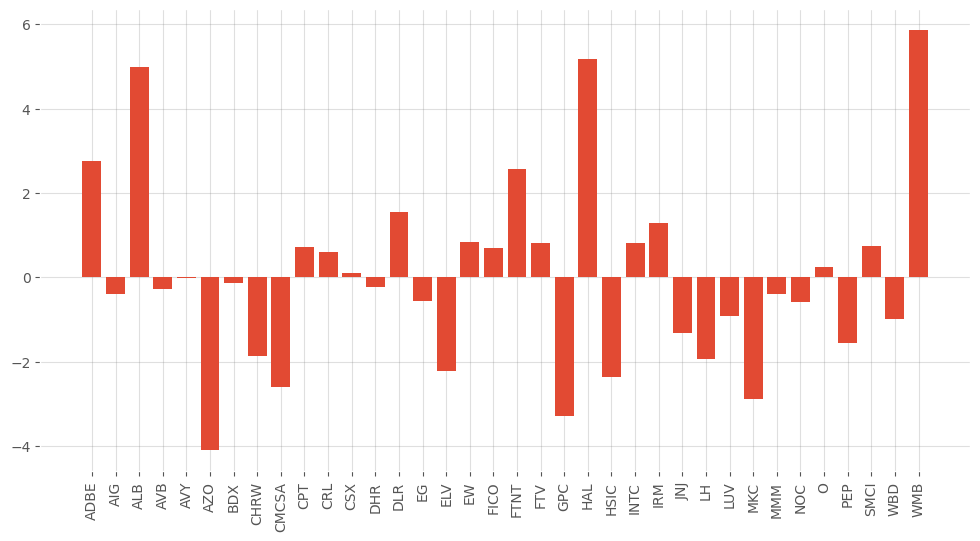

In [69]:
plt.figure(figsize=(12,6))
plt.bar(stock_tickers, weights[3])
plt.xticks(rotation=90)
plt.show()

### <font color = red> Answer 1 is presented in the cell below: </font>

Prof. Roh's Message: 'Sanity check succeeded :)' The order of tickers in X_Test_Raw matches the order in eigen.
Our PCA-based Portfolio:
Return = -5.91%
Volatility = 16.23%
Sharpe = -0.36


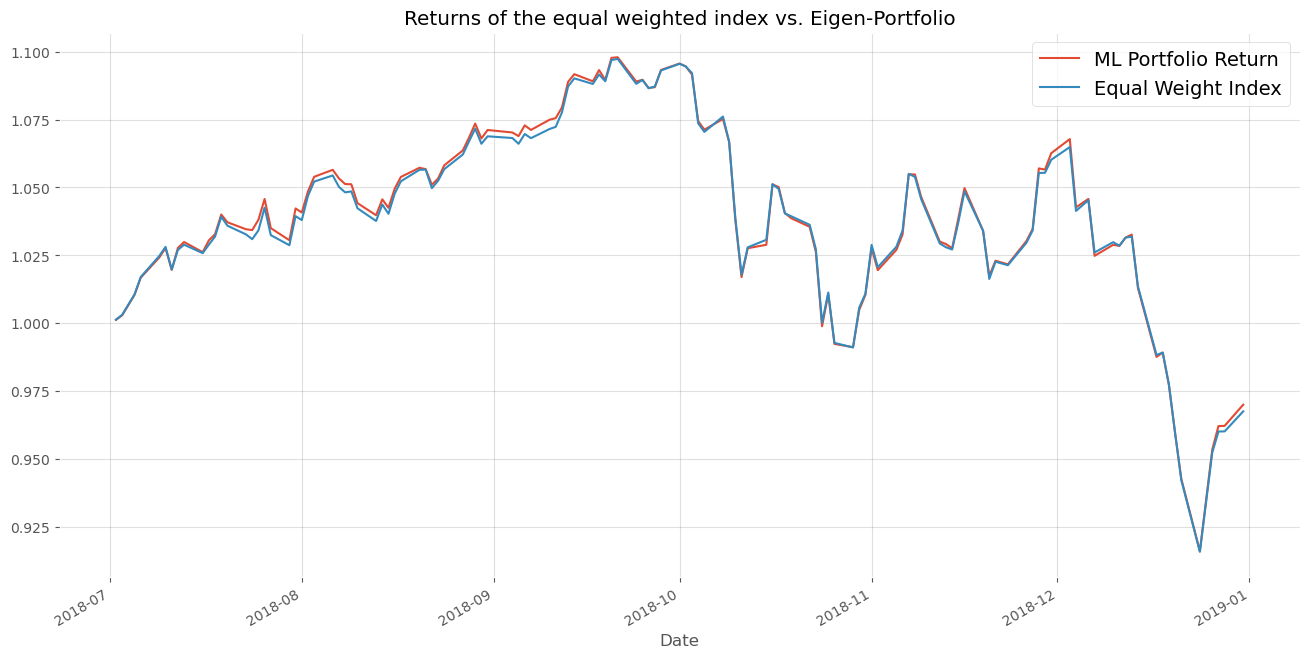

Prof. Roh's Message: 'Sanity check succeeded :)' The order of tickers in X_Test_Raw matches the order in eigen.
Our PCA-based Portfolio:
Return = -100.00%
Volatility = 1733.37%
Sharpe = -0.06


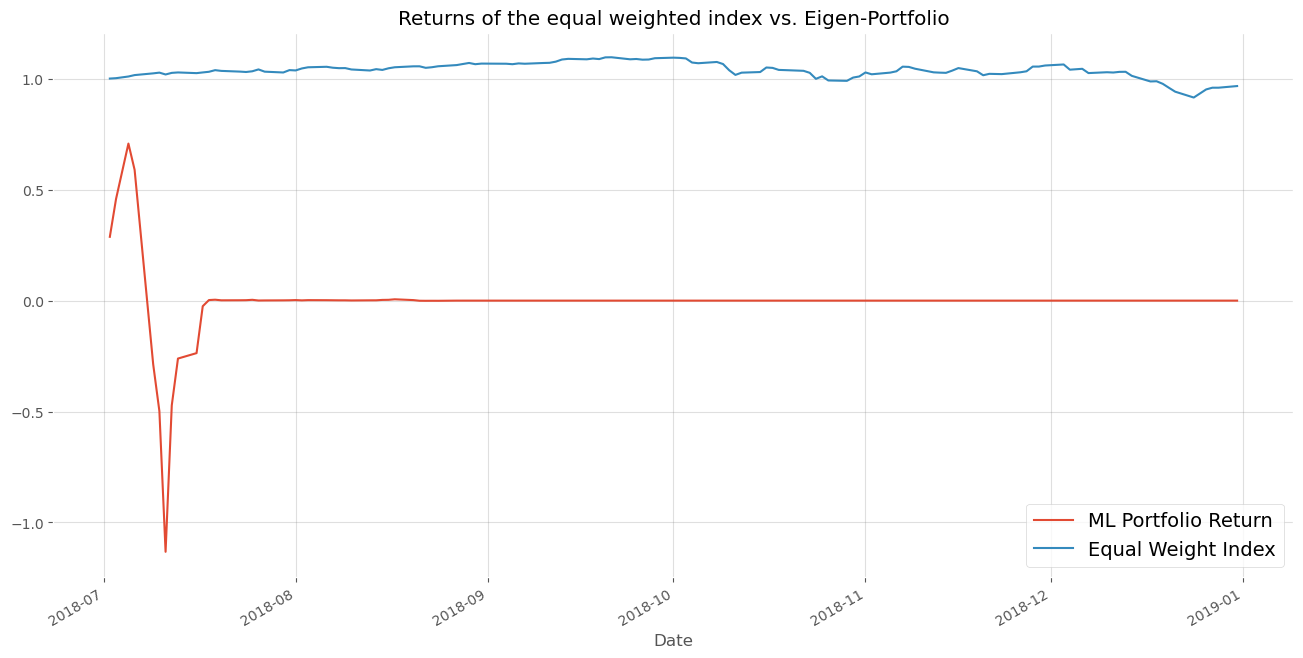

Prof. Roh's Message: 'Sanity check succeeded :)' The order of tickers in X_Test_Raw matches the order in eigen.
Our PCA-based Portfolio:
Return = -43.50%
Volatility = 39.32%
Sharpe = -1.11


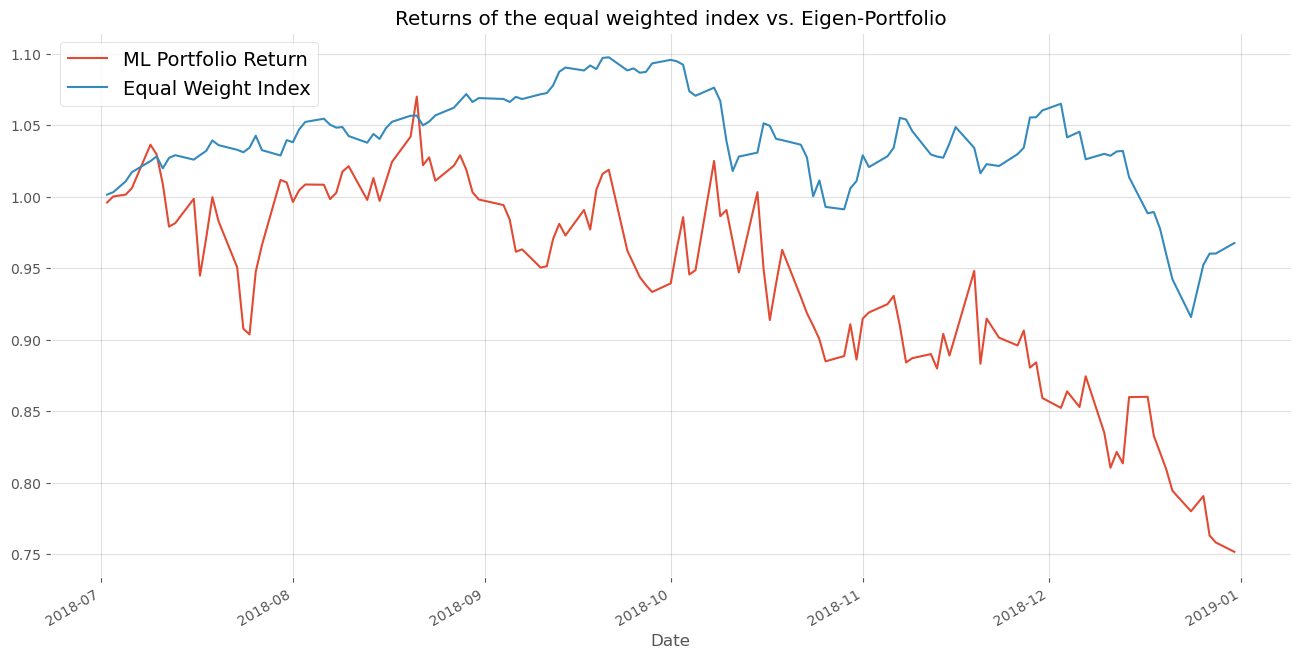

Prof. Roh's Message: 'Sanity check succeeded :)' The order of tickers in X_Test_Raw matches the order in eigen.
Our PCA-based Portfolio:
Return = -100.00%
Volatility = 393.63%
Sharpe = -0.25


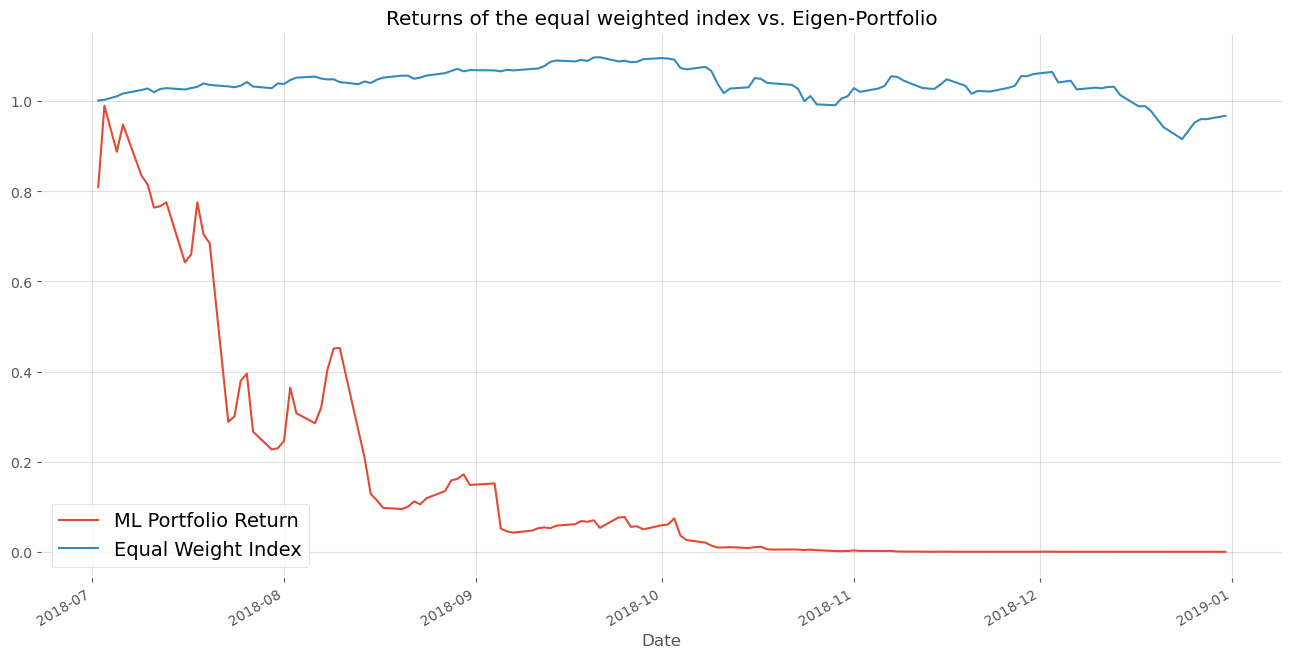

In [73]:
stock_tickers = x.columns.to_list()
X_Test_Raw = x_test_raw
x_test_index = x.iloc[len(x_train):].index


res_ls = []
for idx in range(4):
    rets, vol, sharpe = valid_backtest_PCA_porfolios(eigen = weights[idx])
    res_ls.append((rets, vol, sharpe))

## <font color = blue> 👉 Questions 2 to 7 ask you to build, execute, and backtest a strategy, using both `MACD` and `RSI`. </font>

### <font color = green> Please combine the RSI and MACD strategies and own the stock if both RSI and MACD criteria provide a signal to buy. As to RSI, you will generalize the RSI threshold values to 50.

#### You are asked to build a trading strategy with the following set of rules.

### <font color = green> NOTE: Microsoft (`MSFT`) is our security of interest. The `investment horizon` will be three years between 2015 and 2017; your `capital` is USD 100,000; and there is a USD 5 flat `commission fee` per trade.

- You can go long and short.
<br>

- To calculate RSI, use 14 periods (trading days).
<br>

- Enter a long position under a condition where RSI is below 50 and, at the same time, bullish crossover based on MACD is accomplished.
<br>
    
- Enter a short position under a condition where RSI is above 50 and, at the same time, bearish crossover based on MACD is accomplished.

### <font color = green> NOTE: The MACD crossover strategy is defined as:    
    
- A `bullish` crossover arises when the MACD line turns `upward and crosses` beyond the MACD signal line.
- A `bearish` crossover arises when the MACD line turns `downward and crosses` under the MACD signal line.        
<br>

- The MACD is defined as the `difference` between the `12`-day ***exponential*** moving average and the `26`-day exponential moving average.
- The MACD signal line is then defined as the `9`-day ***exponential*** moving average of the MACD.
    
### <font color = green> NOTE: The RSI is defined as follows:
    
### Calculating the RSI first requires the RS which requires an average value of n-many previous trading days. 
<br>
    |
    
- As discussed, a value of 14 days is common for the RSI calculation. 
<br>
    
- The first RS value requires the price from all 14 of the first trading days. Often, this is a source of confusion with the RSI given successive values only require the most recent. 
   
    
    Step 1. For 14 periods, calculate the difference in price from the current period 
    and the previous period
    
    Step 2. For each period, record each positive change in price as a gain and 
    each negative change as a loss
    
    Step 3. On the 14th period, calculate the arithmetic mean of the gains and losses for 
    the entire 14 day period (e.g. gains / 14 & losses / 14)
    
    Step 4. Use these values to calculate the RS
    
### <center> $ RS = \frac{AverageGain}{AverageLoss} $
    
    Step 5. Use the RS value to calculate the RSI
    
    Step 6. For each proceeding period, use only the previous RSI value 
    to calculate the nextaverage value by multiplying by our lookback 
    period – 1 (e.g., 13 for a lookback of 14).
    
    Step 7. Add the value obtained in Step 6 to the current day’s value 
    (run this for both the gains and losses)
    
### <center> $ RSI = 100 - \frac{100}{1 + RS} $

### Visualize your buy and sell positions.

1. download msft start 2014 to 2018
2. get rsi 14 day period
    - use rsi function 
    - get rs avegain/aveloss
    - use rs to get RSI
    - after day 1, take (last day value X 13 + current day) / 14
3. get MACD 
    - macd = ema_12 - ema_26
    - macd signal = ema_9
4. get positions 
    - long when rsi < 50 and MACD upward > macd signal line
    - short when rsi > 50 and MACD downward < macd signal line

### Below are the lines of code that lead to an answer:

In [147]:
msft=\
yf.download(
    ['MSFT'],
    start = '2014-11-01',
    end = '2018-01-01'
)['Close']

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_54534/242814420.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  yf.download(
[*********************100%***********************]  1 of 1 completed


In [148]:
# get RSI

def get_rsi(df, period_list=[10, 20, 200]):
    """
    Calculate RSI (Relative Strength Index)
    
    Parameters:
    data: pandas df of closing price
    period: RSI period (default [10, 20, 200])
    
    Returns:
    pandas df with RSI values
    """
    # Calculate price changes
    delta = df[df.columns[0]].diff()
    
    for period in period_list:
        # Separate gains and losses
        gain = delta.clip(lower=0)
        loss = -delta.clip(upper=0)
        
        # get first average
        avg_gain = pd.Series(index=df.index, dtype='float64')
        avg_loss = pd.Series(index=df.index, dtype='float64')

        # get first average
        avg_gain.iloc[period] = gain.iloc[1:period+1].mean()    # start from period + 1 since diff() makes first NaN
        avg_loss.iloc[period] = loss.iloc[1:period+1].mean()

        # Calculate rolling averages
        for i in range(period + 1, len(df)): 
            avg_gain.iloc[i] = (avg_gain.iloc[i-1] * (period - 1) + gain.iloc[i]) / period
            avg_loss.iloc[i] = (avg_loss.iloc[i-1] * (period - 1) + loss.iloc[i]) / period

        # Calculate RS (Relative Strength)
        rs = avg_gain / avg_loss
        
        # Calculate RSI
        rsi = 100 - (100 / (1 + rs))

        df[f'rsi_{period}'] = rsi

    return df

def compute_MACD(
    df: pd.DataFrame,
    span: list[int, int, int]
    ) -> pd.DataFrame:
    """
    Compute MACD / get_macd and signal-line for AAPL prices and attach intermediate EWMAs.
    Assumes first col is ticker data

    Parameters
        df : pandas.DataFrame Time-indexed DataFrame containing a column named "AAPL" with price data.
        span : list[int, int, int] Three integers specifying spans for exponential moving averages:
    Returns:
        pandas.DataFrame
    Usage:
        compute_MACD(aapl, [12, 26, 9])
    """
    ticker = df.columns[0]
    df[f"_{span[0]}_ewma"] =\
    (
        df
        [df.columns[0]]
        .ewm(span = span[0]
            )
        .mean()
    )

    df[f"_{span[1]}_ewma"] =\
    (
        df
        [df.columns[0]]
        .ewm(span = span[1]
            )
        .mean()
    )

    df["macd"] =\
    (
        df
        .eval(
            f"`_{span[0]}_ewma` - `_{span[1]}_ewma`"
        )
    )

    df["macd_signal"] =\
    (
        df
        ["macd"]
        .ewm(span = span[2]
            )
        .mean()
    )
    return df

# compute_MACD(msft, [12, 26, 9])

In [149]:
rsi_list = [14]
macd_list = [12, 26, 9]

msft = get_rsi(msft, rsi_list)
msft = compute_MACD(msft, macd_list)

In [150]:
msft = msft.dropna()

In [151]:
msft['positions'] =\
np.where(
    (msft.rsi_14 < 50) & (msft.macd_signal > msft.macd),1,
        np.where((msft.rsi_14 > 50) & (msft.macd_signal < msft.macd), -1, np.nan)
)
msft['positions'] = msft['positions'].ffill().fillna(0)

In [152]:
msft.loc['2015-01-01':]

Ticker,MSFT,rsi_14,_12_ewma,_26_ewma,macd,macd_signal,positions
Date,,,,,,,
2015-01-02,39.933048,45.307526,40.345599,40.515482,-0.169883,-0.140566,1.0
2015-01-05,39.565838,42.291159,40.225545,40.442470,-0.216926,-0.155839,1.0
2015-01-06,38.985111,37.984312,40.034586,40.330737,-0.296151,-0.183903,1.0
2015-01-07,39.480438,43.289249,39.949286,40.265715,-0.316429,-0.210410,1.0
2015-01-08,40.641869,53.363075,40.055886,40.294411,-0.238524,-0.216033,1.0
...,...,...,...,...,...,...,...
2017-12-22,78.792870,57.972783,78.489100,77.600108,0.888992,0.891564,-1.0
2017-12-26,78.691528,57.238613,78.520242,77.680954,0.839289,0.881109,-1.0
2017-12-27,78.977188,58.821644,78.590542,77.776971,0.813571,0.867601,-1.0


In [153]:

msft['trade'] = \
(
    msft['positions'].diff().fillna(0)
)
if msft.at[msft.index[0], 'positions'] != 0:
    msft.at[msft.index[0], 'trade'] = msft.at[msft.index[0], 'positions']
msft['passive_returns'] = \
(
    np.log(
        msft[msft.columns[0]] / 
            msft[msft.columns[0]].shift(1)
    )
).fillna(0)
msft['strategy_returns'] = \
(
    msft['passive_returns'] * msft['positions'].shift(1).fillna(0)
)
msft['cum_passive_returns'] = \
(
    msft['passive_returns'].cumsum().apply(np.exp).fillna(1)
)
msft['cum_strategy_returns'] = \
(
    msft['strategy_returns'].cumsum().apply(np.exp).fillna(1)
)


In [155]:
initial_cap = 100_000
cap = initial_cap
cum_strategy_returns = pd.Series(index=msft.index)

for idx, row in msft.iterrows():
    cap *= np.exp(row['strategy_returns'])
    if row['trade'] !=0:
        cap -= 5
    cum_strategy_returns.loc[idx] = cap

print(f"Final capital ${cap:,.0f}")

Final capital $187,738


In [156]:
msft['cum_strategy_returns'] = cum_strategy_returns / initial_cap

### <font color = red> Answer 2 is presented in the cell below: </font>

In [158]:
from lets_plot import *
LetsPlot.setup_html()

msft_melt = msft.reset_index()
# msft_melt = msft_melt.rename(columns={'index':'Date'}). # optional depending if index is called 'Date'

p =\
(
    ggplot(msft_melt, aes(x='Date')) +
    geom_line(aes(y='MSFT'), color='grey', size=0.7) +
    geom_line(aes(y='_12_ewma'), color='orange', size=0.7,linetype=2) +   # amend sma as required
    geom_line(aes(y='_26_ewma'), color='blue', size=0.7,linetype=2) +
    geom_point(aes(y='MSFT'), data=msft_melt[msft_melt['trade']>0.0], color='green', size=3) +       # amend trade as required
    geom_point(aes(y='MSFT'), data=msft_melt[msft_melt['trade']<-0.0], color='orange', size=3) +
    ggtitle("Price Action with Signals") +
    ylab("Stock Price") +
    xlab("Date") +
    ggsize(1200, 500) 
)


display(p)

p =\
(
    ggplot(msft_melt, aes(x='Date')) +
    # geom_line(aes(y='MSFT'), color='grey', size=0.7) +
    geom_line(aes(y='macd'), color='red', size=0.7,linetype=1) +   # amend sma as required
    geom_line(aes(y='macd_signal'), color='blue', size=0.7,linetype=1) +
    geom_point(aes(y='macd'), data=msft_melt[msft_melt['trade']>0.0], color='green', size=3) +       # amend trade as required
    geom_point(aes(y='macd'), data=msft_melt[msft_melt['trade']<-0.0], color='orange', size=3) +
    ggtitle("Price Action with Signals") +
    ylab("Stock Price") +
    xlab("Date") +
    ggsize(1200, 500) 
)


display(p)

p =\
(
    ggplot(msft_melt, aes(x='Date')) +
    # geom_line(aes(y='MSFT'), color='grey', size=0.7) +
    geom_line(aes(y='rsi_14'), color='red', size=0.7,linetype=1) +   # amend sma as required
    # geom_line(aes(y='macd_signal'), color='blue', size=0.7,linetype=1) +
    geom_point(aes(y='rsi_14'), data=msft_melt[msft_melt['trade']>0.0], color='green', size=3) +       # amend trade as required
    geom_point(aes(y='rsi_14'), data=msft_melt[msft_melt['trade']<-0.0], color='orange', size=3) +
    ggtitle("Price Action with Signals") +
    ylab("Stock Price") +
    xlab("Date") +
    ggsize(1200, 500) 
)


display(p)

### <font color = blue> 👉 Question 3</font>. How much in cumulative returns could you have had as a result of the RSI strategy?

### Below are the lines of code that lead to an answer:

In [159]:
msft['cum_strategy_returns'].iloc[-1]

1.877381311876304

### <font color = red> Answer 3 </font>

    The answer is ____________ % .

In [160]:
f"The answer is {msft['cum_strategy_returns'].iloc[-1]:.2%}"

'The answer is 187.74%'

### <font color = blue> 👉 Question 4</font>. Now please find the `five` worst drawdown periods over the investment horizon and provide their net drawdown in % and duration, respectively.

### <font color = green> The question asks you to find the five worst drawdown periods, beyond identifying max drawdown (MDD).

### Below are the lines of code that lead to an answer:

In [162]:
# daily_drawdown = cum_returns / cum_returns.cummax() - 1
msft['daily_drawdown'] = msft['cum_strategy_returns'] / msft['cum_strategy_returns'].cummax() - 1
# take date column out and cumsum for periods
dd_reset = msft.reset_index()
dd_reset['period'] = (dd_reset['daily_drawdown'] == 0).cumsum()
# find nodes with 0 value i.e. highpoints
dd_nonzero = dd_reset[dd_reset['daily_drawdown'] != 0]
# aggregate by period
period_stats = dd_nonzero.groupby('period').agg(
    start_date = ('Date', 'min'),
    end_date = ('Date', 'max'),
    avg_dd = ('daily_drawdown', 'mean'),
    max_dd = ('daily_drawdown', 'min'),
    duration=('daily_drawdown', 'count')
).sort_values(by='avg_dd',ascending=True)


## printing drawdowns
for i, row in enumerate(period_stats[:5].itertuples(), start=1):
    ordinal = f"{i}{'tsnrhtdd'[i%5*(i%100^15>4>i%10)::4]}"
    print(f"The {ordinal} worst drawdown period : Net drawdown {-row.max_dd:.2%}% | Duration {row.duration} Days\n")

The 1st worst drawdown period : Net drawdown 36.16%% | Duration 396 Days

The 2nd worst drawdown period : Net drawdown 10.94%% | Duration 59 Days

The 3rd worst drawdown period : Net drawdown 7.41%% | Duration 76 Days

The 4th worst drawdown period : Net drawdown 4.67%% | Duration 37 Days

The 5th worst drawdown period : Net drawdown 4.27%% | Duration 8 Days



### <font color = red> Answer 4 </font>

    The Worst drawdown period     : Net drawdown ____________ % | Duration ____________ Days
    
    The 2nd worst drawdown period : Net drawdown ____________ % | Duration ____________ Days
     
    The 3rd worst drawdown period : Net drawdown ____________ % | Duration ____________ Days
         
    The 4th worst drawdown period : Net drawdown ____________ % | Duration ____________ Days
    
    The 5th worst drawdown period : Net drawdown ____________ % | Duration ____________ Days

### <font color = blue> 👉 Question 5</font>. Within the investment horizon, please calculate annual returns for each of the three years and then find the year that performs better than average vs. less than average annual returns.

### Below are the lines of code that lead to an answer:

<AxesSubplot:xlabel='Date'>

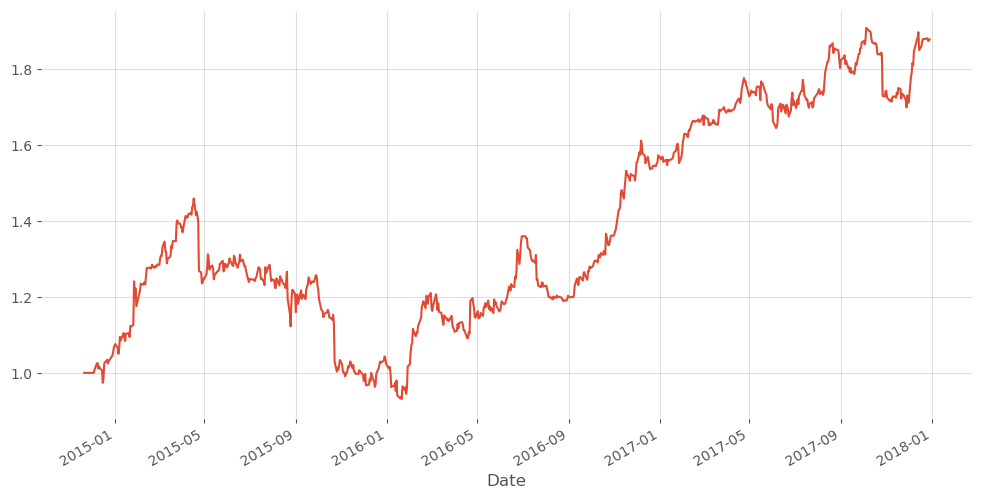

In [163]:
msft['cum_strategy_returns'].plot(figsize=[12,6])

### <font color = red> Answer 5 </font>

    Below average year(s) : ____________ 
    
    Above average year(s) : ____________ 
     

In [164]:
# Above and below average years
splits = [
            '2015-01-01',
            '2016-01-01',
            '2017-01-01',
            '2018-01-01',
]

dct = {}
ar_dct = {}

for idx, year in enumerate([2015, 2016, 2017]):
    dct[year] = msft.loc[splits[idx]: splits[idx+1]]

for year, df in dct.items():
    cum_rets = df['strategy_returns'].cumsum().apply(np.exp).fillna(1)
    ar_dct[year] = cum_rets.iloc[-1] - 1

avg = (np.mean(list(ar_dct.values())))
above = [k for k, v in ar_dct.items() if v > avg]
below = [k for k, v in ar_dct.items() if v < avg]

f"    Below average year(s) : {below}. Above average year(s) : {above}" 

'    Below average year(s) : [2015, 2017]. Above average year(s) : [2016]'

###  <font color = blue> 👉 Question 6. </font> What's the annualized Sharpe ratio of the current investment strategy?

### Below are the lines of code that lead to an answer:

In [165]:
def compute_sharpe_ratio(daily_returns):
    """
    get_sharpe Calculate the annualized Sharpe ratio from a series of daily returns.
    Annualized Sharpe ratio computed as:
                sqrt(252) * mean(daily_returns) / std(daily_returns)
    - Assumes 252 trading days per year for annualization. Adjust the
      multiplier for a different convention.
    - Input should be returns (not prices). Convert prices to returns before
      calling this function.
    Parameters:
        daily_returns : array-like (pd.Series or np.ndarray)
    Returns:
        float
    Usage:
        compute_sharpe_ratio(df['strategy_returns'])
    """
    return np.sqrt(252) * daily_returns.mean() / daily_returns.std(ddof = 1)

s = compute_sharpe_ratio(msft['strategy_returns'])



### <font color = red> Answer 6 </font>
    
    Sharpe ratio: __________
    

In [166]:
f"Sharpe ratio: {s:.5f}"

'Sharpe ratio: 0.90994'

###  <font color = blue> 👉 Question 7. </font> Please compare the above Sharpe ratio deploying RSI-MACD combined strategy, relative to the Sharpe ratio utilizing MACD strategy only. Which investment strategy performs better based on the Sharpe ratio?

### Below are the lines of code that lead to an answer:

In [167]:
msft

Ticker,MSFT,rsi_14,_12_ewma,_26_ewma,macd,macd_signal,positions,trade,passive_returns,strategy_returns,cum_passive_returns,cum_strategy_returns,daily_drawdown
Date,,,,,,,,,,,,,
2014-11-21,40.974934,58.919505,41.439594,41.399770,0.039824,0.084006,0.0,0.0,0.000000,0.000000,1.000000,1.000000,0.000000
2014-11-24,40.641869,54.080377,41.307764,41.320488,-0.012724,0.064100,0.0,0.0,-0.008162,-0.000000,0.991871,1.000000,0.000000
2014-11-25,40.539406,52.647826,41.182219,41.241201,-0.058982,0.038917,0.0,0.0,-0.002524,-0.000000,0.989371,1.000000,0.000000
2014-11-26,40.778507,55.603267,41.116879,41.195488,-0.078609,0.014980,0.0,0.0,0.005881,0.000000,0.995206,1.000000,0.000000
2014-11-28,40.829750,56.233727,41.070777,41.160225,-0.089449,-0.006211,0.0,0.0,0.001256,0.000000,0.996457,1.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-12-22,78.792870,57.972783,78.489100,77.600108,0.888992,0.891564,-1.0,0.0,0.000117,-0.000117,1.922953,1.878040,-0.015212
2017-12-26,78.691528,57.238613,78.520242,77.680954,0.839289,0.881109,-1.0,0.0,-0.001287,0.001287,1.920480,1.880459,-0.013943
2017-12-27,78.977188,58.821644,78.590542,77.776971,0.813571,0.867601,-1.0,0.0,0.003624,-0.003624,1.927451,1.873657,-0.017510


In [168]:
msft['positions_macd'] = \
(
    np.where( msft.macd_signal > msft.macd, 1, -1)
)
msft['trade_macd'] = \
(
    msft['positions_macd'].diff().fillna(0)
)
if msft.at[msft.index[0], 'positions_macd'] != 0:
    msft.at[msft.index[0], 'trade_macd'] = msft.at[msft.index[0], 'positions_macd']

msft['strategy_returns_macd'] = \
(
    msft['passive_returns'] * msft['positions_macd'].shift(1).fillna(0)
)

msft['cum_strategy_returns_macd'] = \
(
    msft['strategy_returns_macd'].cumsum().apply(np.exp).fillna(1)
)


In [169]:
s_ = compute_sharpe_ratio(msft['strategy_returns_macd'])

In [170]:
s > s_

True

### <font color = red> Answer 7 </font>
    
    __________________________ strategy performs better.
    

In [171]:
f" combined strategy performs better"

' combined strategy performs better'

> 💯 “Thank you for putting your efforts into the exercise questions” 😊